In [1]:
import pandas as pd

data = {
    'date': [
        '2024-01-01','2024-01-01','2024-01-01',
        '2024-01-02','2024-01-02','2024-01-02',
        '2024-01-03','2024-01-03','2024-01-03',
        '2024-01-04','2024-01-04','2024-01-04',
        '2024-01-05','2024-01-05','2024-01-05',
        '2024-01-06','2024-01-06','2024-01-06',
        '2024-01-07','2024-01-07','2024-01-07',
    ],
    'item': [
        'Espresso','Cappuccino','Croissant',
        'Latte','Cold Brew','Muffin',
        'Espresso','Latte','Sandwich',
        'Cappuccino','Croissant','Cold Brew',
        'Espresso','Muffin','Latte',
        'Cold Brew','Sandwich','Cappuccino',
        'Latte','Espresso','Croissant',
    ],
    'category': [
        'Coffee','Coffee','Food',
        'Coffee','Coffee','Food',
        'Coffee','Coffee','Food',
        'Coffee','Food','Coffee',
        'Coffee','Food','Coffee',
        'Coffee','Food','Coffee',
        'Coffee','Coffee','Food',
    ],
    'quantity': [3,2,4, 5,3,2, 4,6,1, 2,5,3, 6,4,3, 2,3,4, 5,3,2],
    'price':    [2.5,3.5,2.0, 4.0,4.0,2.75, 2.5,4.0,5.0, 3.5,2.0,4.0,
                 2.5,2.75,4.0, 4.0,5.0,3.5, 4.0,2.5,2.0]
}

df = pd.DataFrame(data)
df['revenue'] = df['quantity'] * df['price']   # calculate revenue
df.to_csv('coffee_sales.csv', index=False)      # save as CSV
print("✅ Dataset created!")
print(df.head())                                 # preview first 5 rows

✅ Dataset created!
         date        item category  quantity  price  revenue
0  2024-01-01    Espresso   Coffee         3    2.5      7.5
1  2024-01-01  Cappuccino   Coffee         2    3.5      7.0
2  2024-01-01   Croissant     Food         4    2.0      8.0
3  2024-01-02       Latte   Coffee         5    4.0     20.0
4  2024-01-02   Cold Brew   Coffee         3    4.0     12.0


LOADING THE DATA

In [2]:
#Importing libraries and loading data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Loading the CSV file into a DataFrame
df = pd.read_csv('coffee_sales.csv')

# Converting date column to proper date type
df['date'] = pd.to_datetime(df['date'])

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Data loaded successfully!
Shape: 21 rows × 6 columns


EXPLORING DATA

In [3]:
# Exploring the data

print("=== First 5 rows ===")
display(df.head())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Basic statistics ===")
display(df.describe())

print("\n=== Any missing values? ===")
print(df.isnull().sum())

=== First 5 rows ===


,date,item,category,quantity,price,revenue
0,2024-01-01,Espresso,Coffee,3,2.5,7.5
1,2024-01-01,Cappuccino,Coffee,2,3.5,7.0
2,2024-01-01,Croissant,Food,4,2.0,8.0
3,2024-01-02,Latte,Coffee,5,4.0,20.0
4,2024-01-02,Cold Brew,Coffee,3,4.0,12.0



=== Data types ===
date        datetime64[ns]
item                object
category            object
quantity             int64
price              float64
revenue            float64
dtype: object

=== Basic statistics ===


,date,quantity,price,revenue
count,21,21.000000,21.000000,21.000000
mean,2024-01-04 00:00:00,3.428571,3.333333,11.166667
min,2024-01-01 00:00:00,1.000000,2.000000,4.000000
25%,2024-01-02 00:00:00,2.000000,2.500000,7.500000
50%,2024-01-04 00:00:00,3.000000,3.500000,10.000000
75%,2024-01-06 00:00:00,4.000000,4.000000,14.000000
max,2024-01-07 00:00:00,6.000000,5.000000,24.000000
std,NaN,1.398979,0.936527,5.320558



=== Any missing values? ===
date        0
item        0
category    0
quantity    0
price       0
revenue     0
dtype: int64


REVENUE ANALYSIS

In [4]:
# Revenue analysis

# Total revenue per day
daily_revenue = df.groupby('date')['revenue'].sum().reset_index()
daily_revenue.columns = ['date', 'total_revenue']

print("=== Daily Revenue ===")
display(daily_revenue)

# Best and worst day
best_day = daily_revenue.loc[daily_revenue['total_revenue'].idxmax()]
worst_day = daily_revenue.loc[daily_revenue['total_revenue'].idxmin()]

print(f"\n💰 Best day:  {best_day['date'].date()} — ${best_day['total_revenue']:.2f}")
print(f"📉 Worst day: {worst_day['date'].date()} — ${worst_day['total_revenue']:.2f}")

# Total revenue overall
print(f"\n🏆 Total 7-day revenue: ${df['revenue'].sum():.2f}")

=== Daily Revenue ===


,date,total_revenue
0,2024-01-01,22.5
1,2024-01-02,37.5
2,2024-01-03,39.0
3,2024-01-04,29.0
4,2024-01-05,38.0
5,2024-01-06,37.0
6,2024-01-07,31.5



💰 Best day:  2024-01-03 — $39.00
📉 Worst day: 2024-01-01 — $22.50

🏆 Total 7-day revenue: $234.50


BEST SELLER

In [5]:
# Best sellers

# Revenue by item
item_revenue = df.groupby('item')['revenue'].sum().sort_values(ascending=False)
print("=== Revenue by Item ===")
print(item_revenue)

# Revenue by category
cat_revenue = df.groupby('category')['revenue'].sum()
print("\n=== Revenue by Category ===")
print(cat_revenue)

# Most sold item by quantity
top_qty = df.groupby('item')['quantity'].sum().sort_values(ascending=False)
print("\n=== Most Sold by Quantity ===")
print(top_qty)

=== Revenue by Item ===
item
Latte         76.0
Espresso      40.0
Cold Brew     32.0
Cappuccino    28.0
Croissant     22.0
Sandwich      20.0
Muffin        16.5
Name: revenue, dtype: float64

=== Revenue by Category ===
category
Coffee    176.0
Food       58.5
Name: revenue, dtype: float64

=== Most Sold by Quantity ===
item
Latte         19
Espresso      16
Croissant     11
Cold Brew      8
Cappuccino     8
Muffin         6
Sandwich       4
Name: quantity, dtype: int64


CHARTS

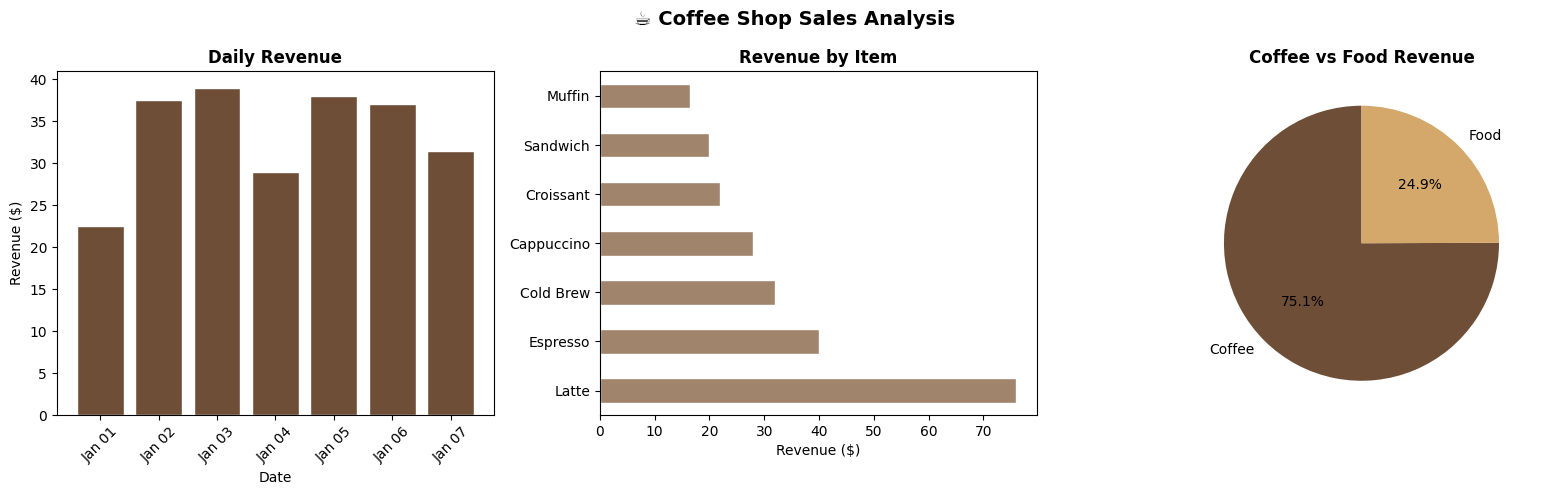

✅ Chart saved as sales_analysis.png


In [6]:
# Charts

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('☕ Coffee Shop Sales Analysis', fontsize=14, fontweight='bold')

# Daily Revenue Bar Chart
axes[0].bar(
    daily_revenue['date'].dt.strftime('%b %d'),
    daily_revenue['total_revenue'],
    color='#6f4e37', edgecolor='white'
)
axes[0].set_title('Daily Revenue', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Revenue by Item
item_revenue.plot(kind='barh', ax=axes[1], color='#a0856c', edgecolor='white')
axes[1].set_title('Revenue by Item', fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('')

# Category Pie Chart
axes[2].pie(
    cat_revenue,
    labels=cat_revenue.index,
    autopct='%1.1f%%',
    colors=['#6f4e37','#d4a76a'],
    startangle=90
)
axes[2].set_title('Coffee vs Food Revenue', fontweight='bold')

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as sales_analysis.png")

SUMMARY

In [8]:
#Final business summary

total_rev = df['revenue'].sum()
best_item = item_revenue.idxmax()
top_cat = cat_revenue.idxmax()

print("=" * 40)
print("   COFFEE SHOP — WEEKLY REPORT")
print("=" * 40)
print(f"📅 Period       : Jan 1–7, 2024")
print(f"💰 Total Revenue: ${total_rev:.2f}")
print(f"🏆 Best Day     : {best_day['date'].date()} (${best_day['total_revenue']:.2f})")
print(f"☕ Top Item     : {best_item}")
print(f"📦 Top Category : {top_cat}")
print(f"📈 Avg Daily Rev: ${total_rev/7:.2f}")
print("=" * 40)


   COFFEE SHOP — WEEKLY REPORT
📅 Period       : Jan 1–7, 2024
💰 Total Revenue: $234.50
🏆 Best Day     : 2024-01-03 ($39.00)
☕ Top Item     : Latte
📦 Top Category : Coffee
📈 Avg Daily Rev: $33.50
